## Часть 1: Подготовка данных
### Создание датакласса

Реализуйте собственный класс TinyImageNetDataset, наследующий от torch.utils.data.Dataset:

    Метод __init__: инициализация путей к данным, загрузка списка изображений и меток
    Метод __len__: возврат количества примеров в датасете
    Метод __getitem__: загрузка и возврат одного примера (изображение + метка)

In [1]:
import os
import random
from PIL import Image
import numpy as np
import pandas as pd
from collections import Counter, defaultdict

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models

from sklearn.model_selection import StratifiedShuffleSplit, StratifiedKFold
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

import matplotlib.pyplot as plt
import seaborn as sns

import cv2
import albumentations as A
from albumentations.pytorch import ToTensorV2

from tqdm import tqdm

torch.manual_seed(42)
np.random.seed(42)
random.seed(42)


/home/kalex/.local/lib/python3.11/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


In [2]:
class TinyImageNetDataset(Dataset):
    def __init__(self, root_dir, split='train', transform=None, num_classes=-1):
        super().__init__()

        self.root_dir = root_dir
        self.split = split
        self.transform = transform

        with open(os.path.join(root_dir, 'wnids.txt'), 'r') as f:
            all_class_names = [line.strip() for line in f]

        if num_classes > 0 and num_classes <= len(all_class_names):
            self.class_names = all_class_names[:num_classes]
        else:
            self.class_names = all_class_names

        self.class_to_idx = {name: i for i, name in enumerate(self.class_names)}

        self.samples = []
        if split == 'train':
            train_dir = os.path.join(root_dir, 'train')
            for cls in self.class_names:
                img_dir = os.path.join(train_dir, cls, 'images')
                if not os.path.exists(img_dir):
                    continue
                for img_name in os.listdir(img_dir):
                    img_path = os.path.join(img_dir, img_name)
                    label = self.class_to_idx[cls]
                    self.samples.append((img_path, label))

        elif split == 'val':
            val_dir = os.path.join(root_dir, 'val', 'images')
            anno_path = os.path.join(root_dir, 'val', 'val_annotations.txt')

            label_map = {}
            with open(anno_path, 'r') as f:
                for line in f:
                    img_name, cls, *_ = line.strip().split('\t')
                    label_map[img_name] = cls

            for img_name in os.listdir(val_dir):
                cls = label_map.get(img_name)
                if cls and cls in self.class_to_idx:
                    img_path = os.path.join(val_dir, img_name)
                    label = self.class_to_idx[cls]
                    self.samples.append((img_path, label))

        else:
            test_dir = os.path.join(root_dir, 'test', 'images')
            for img_name in os.listdir(test_dir):
                img_path = os.path.join(test_dir, img_name)
                self.samples.append((img_path, -1))  # тест без меток


    def __len__(self):
        return len(self.samples)


    def __getitem__(self, idx):
        img_path, label = self.samples[idx]
        img = Image.open(img_path).convert('RGB')
        if self.transform:
            img = self.transform(img)
        return img, label



train_transform = transforms.Compose([
    transforms.Resize((72, 72)),                    
    transforms.RandomResizedCrop(64, scale=(0.8, 1.0)),  
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1),
    transforms.ToTensor(),                     
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

val_transform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

root = "data/tiny-imagenet-200"

train_dataset = TinyImageNetDataset(root, split='train', transform=train_transform)
val_dataset = TinyImageNetDataset(root, split='val', transform=val_transform)

train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True, num_workers=8) # num_workers=>1 does not work on macos
val_loader = DataLoader(val_dataset, batch_size=8, shuffle=False, num_workers=8)    # num_workers=>1 does not work on macos



print(f"Train size: {len(train_dataset)}")
print(f"Val size: {len(val_dataset)}")
print(f"Классов: {len(train_dataset.class_names)}")

Train size: 100000
Val size: 10000
Классов: 200


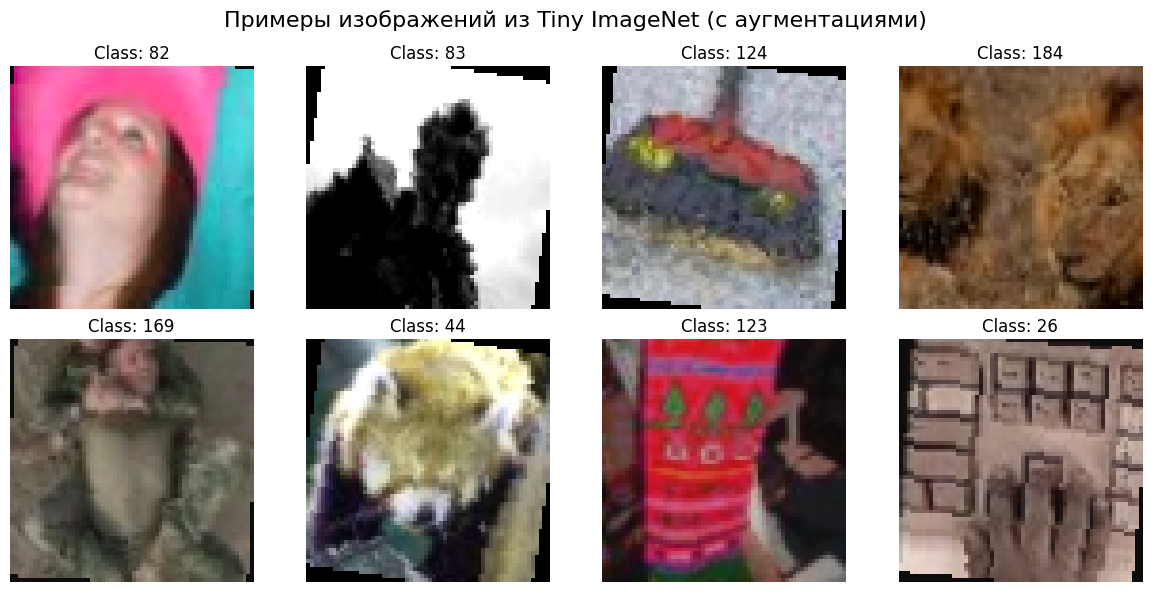

Размер батча: torch.Size([8, 3, 64, 64])
Диапазон значений: [-2.118, 2.640]
Метки классов: [82, 83, 124, 184, 169, 44, 123, 26]
Всего классов в датасете: 200
Примеры названий классов: ['n02124075', 'n04067472', 'n04540053', 'n04099969', 'n07749582']


In [3]:
def denormalize(img_tensor):
    """Вернём изображение из нормализованного диапазона в [0,1]"""
    mean = torch.tensor([0.485, 0.456, 0.406]).view(1, 1, 3)
    std = torch.tensor([0.229, 0.224, 0.225]).view(1, 1, 3)
    img = img_tensor.permute(1, 2, 0) * std + mean
    return img.clamp(0, 1)

def display_dataset(loader):
    images, labels = next(iter(loader))
    images_vis = images.permute(0, 2, 3, 1)

    images_vis = torch.stack([denormalize(img) for img in images])

    plt.figure(figsize=(12, 6))
    for i in range(8):
        plt.subplot(2, 4, i+1)
        plt.imshow(images_vis[i])
        plt.title(f"Class: {labels[i].item()}")
        plt.axis('off')
    plt.suptitle("Примеры изображений из Tiny ImageNet (с аугментациями)", fontsize=16)
    plt.tight_layout()
    plt.show()

    print(f"Размер батча: {images.shape}")
    print(f"Диапазон значений: [{images.min():.3f}, {images.max():.3f}]")
    print(f"Метки классов: {labels.tolist()}")
    print(f"Всего классов в датасете: {len(train_dataset.class_names)}")
    print(f"Примеры названий классов: {train_dataset.class_names[:5]}")


display_dataset(train_loader)

## Часть 2: Базовая архитектура ResNet18

### 2.1. Реализация Basic Block

Создайте базовый residual блок со следующей структурой:

```
Input
  ↓
Conv2d(kernel_size=3, padding=1, stride=stride)
  ↓
BatchNorm2d
  ↓
ReLU
  ↓
Conv2d(kernel_size=3, padding=1, stride=1)
  ↓
BatchNorm2d
  ↓
  + ← Skip Connection (с возможностью downsample)
  ↓
ReLU
  ↓
Output
```

**Важно:**
- Если входные и выходные размерности не совпадают, используйте skip connection с Conv2d(1x1) + BatchNorm2d
- Первый residual блок может иметь stride=2 для уменьшения пространственного размера


In [4]:
class BasicBlock(nn.Module):
    def __init__(self, in_channels, out_channels, stride=1, activation=nn.ReLU(inplace=True)):
        super().__init__()

        self.conv1 = nn.Conv2d(in_channels, out_channels, 3, stride=1, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(out_channels)
        self.activation = activation

        self.conv2 = nn.Conv2d(out_channels, out_channels, 3, stride=1, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(out_channels)

        self.downsample = nn.Identity()
        if in_channels != out_channels:
            self.downsample = nn.Sequential(
                nn.Conv2d(in_channels, out_channels, kernel_size=1, padding=0),
                nn.BatchNorm2d(out_channels)
            )



    def forward(self, x):
        x_ident = self.downsample(x)

        out = self.activation(self.bn1(self.conv1(x)))
        
        out = self.bn2(self.conv2(out))

        out += x_ident
        out = self.activation(out)

        return out


basic_block = BasicBlock(64, 64)
test_input = torch.randn(2, 64, 32, 32)

output = basic_block(test_input)

In [5]:
# ResNet 18 на 11kk параметров
class CustomResNet18(nn.Module):
    def __init__(self, num_classes=200):
        super().__init__()

        self.num_classes = num_classes

        self.conv1 = nn.Conv2d(3, 64, kernel_size=7, stride=1, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(64)
        self.relu = nn.ReLU(inplace=True)
        self.maxpool = nn.MaxPool2d(2)

        self.bb_0_0 = BasicBlock(64, 64)
        self.bb_0_1 = BasicBlock(64, 64)

        self.bb_1_0 = BasicBlock(64, 128)
        self.bb_1_1 = BasicBlock(128, 128)
        
        self.bb_2_0 = BasicBlock(128, 256)
        self.bb_2_1 = BasicBlock(256, 256)

        self.bb_3_0 = BasicBlock(256, 512)
        self.bb_3_1 = BasicBlock(512, 512)

        self.adaptive_pooling = nn.AdaptiveAvgPool2d((1, 1))
        self.fc = nn.Linear(512, num_classes)


    def forward(self, x):
        x = self.relu(self.bn1(self.conv1(x)))

        x = self.maxpool(x)

        x = self.bb_0_0(x)
        x = self.bb_0_1(x)

        x = self.bb_1_0(x)
        x = self.bb_1_1(x)

        x = self.bb_2_0(x)
        x = self.bb_2_1(x)

        x = self.bb_3_0(x)
        x = self.bb_3_1(x)

        x = self.adaptive_pooling(x)
        x = x.view(x.size(0), -1)

        x = self.fc(x)
        
        return x

In [6]:
model = CustomResNet18(num_classes=10)
test_input = torch.randn(1, 3, 224, 224)

output = model(test_input)

total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f" Всего параметров: {total_params:,}")
print(f" Обучаемых параметров: {trainable_params:,}")

 Всего параметров: 11,182,538
 Обучаемых параметров: 11,182,538


In [7]:
# ResNet18 на 3kk параметров
class CustomSmallResNet18(nn.Module):
    def __init__(self, num_classes=200):
        super().__init__()

        self.num_classes = num_classes

        self.conv1 = nn.Conv2d(3, 64, kernel_size=7, stride=1, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(64)
        self.relu = nn.ReLU(inplace=True)
        self.maxpool = nn.MaxPool2d(2)

        self.bb_0_0 = BasicBlock(64, 64)
        self.bb_0_1 = BasicBlock(64, 64)

        self.bb_1_0 = BasicBlock(64, 128)
        self.bb_1_1 = BasicBlock(128, 128)

        self.bb_2_0 = BasicBlock(128, 256)
        self.bb_2_1 = BasicBlock(256, 256)

        # self.bb_3_0 = BasicBlock(256, 512)
        # self.bb_3_1 = BasicBlock(512, 512)

        self.adaptive_pooling = nn.AdaptiveAvgPool2d((1, 1))
        self.fc = nn.Linear(256, num_classes)


    def forward(self, x):
        x = self.relu(self.bn1(self.conv1(x)))

        x = self.maxpool(x)

        x = self.bb_0_0(x)
        x = self.bb_0_1(x)

        x = self.bb_1_0(x)
        x = self.bb_1_1(x)

        x = self.bb_2_0(x)
        x = self.bb_2_1(x)

        # x = self.bb_3_0(x)
        # x = self.bb_3_1(x)

        x = self.adaptive_pooling(x)
        x = x.view(x.size(0), -1)

        x = self.fc(x)

        return x

In [8]:
model = CustomSmallResNet18(num_classes=10)
test_input = torch.randn(1, 3, 224, 224)

output = model(test_input)

total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f" Всего параметров: {total_params:,}")
print(f" Обучаемых параметров: {trainable_params:,}")

 Всего параметров: 2,785,738
 Обучаемых параметров: 2,785,738


## Заготовки

In [9]:
from tqdm import tqdm
import torch

def train_epoch(model, train_loader, optimizer, criterion, device):
    """
    Функция для одного эпоха обучения

    Args:
        model: модель для обучения
        train_loader: DataLoader с тренировочными данными
        optimizer: оптимизатор
        criterion: функция потерь
        device: устройство (cpu/cuda)

    Returns:
        train_loss: средняя потеря за эпох
        train_acc: средняя точность за эпох
    """
    model.train()  # Переводим модель в режим обучения

    running_loss = 0.0
    correct = 0
    total = 0

    pbar = tqdm(train_loader, desc="Training", leave=False)

    for batch_idx, (data, target) in enumerate(pbar):
        # Перемещаем данные на устройство
        data, target = data.to(device), target.to(device)

        # Обнуляем градиенты
        optimizer.zero_grad()

        # Прямой проход
        outputs = model(data)

        # Вычисление потерь
        loss = criterion(outputs, target)

        # Обратный проход
        loss.backward()

        # Шаг оптимизатора
        optimizer.step()

        # Статистика
        running_loss += loss.item()

        # Вычисление точности
        _, predicted = torch.max(outputs.data, 1)
        total += target.size(0)
        correct += (predicted == target).sum().item()

        # Обновление прогресс-бара
        current_loss = running_loss / (batch_idx + 1)
        current_acc = 100.0 * correct / total if total > 0 else 0.0
        pbar.set_postfix({
            'loss': f'{current_loss:.4f}',
            'acc': f'{current_acc:.2f}%'
        })

    # Вычисление средних значений за эпоху
    train_loss = running_loss / len(train_loader)
    train_acc = 100.0 * correct / total if total > 0 else 0.0

    return train_loss, train_acc

In [10]:
from tqdm import tqdm
import torch

def validate_epoch(model, val_loader, criterion, device):
    """
    Функция для валидации модели

    Args:
        model: модель для валидации
        val_loader: DataLoader с валидационными данными
        criterion: функция потерь
        device: устройство (cpu/cuda)

    Returns:
        val_loss: средняя потеря на валидации
        val_acc: средняя точность на валидации
    """
    model.eval()  # Переводим модель в режим оценки

    running_loss = 0.0
    correct = 0
    total = 0

    pbar = tqdm(val_loader, desc="Validation", leave=False)

    with torch.no_grad():  # Отключаем вычисление градиентов
        for batch_idx, (data, target) in enumerate(pbar):
            # Перемещаем данные на устройство
            data, target = data.to(device), target.to(device)

            # Прямой проход
            outputs = model(data)

            # Вычисление потерь
            loss = criterion(outputs, target)
            running_loss += loss.item()

            # Вычисление точности
            _, predicted = torch.max(outputs.data, 1)
            total += target.size(0)
            correct += (predicted == target).sum().item()

            # Обновление прогресс-бара
            current_loss = running_loss / (batch_idx + 1)
            current_acc = 100.0 * correct / total if total > 0 else 0.0
            pbar.set_postfix({
                'loss': f'{current_loss:.4f}',
                'acc': f'{current_acc:.2f}%'
            })

    # Вычисление средних значений
    val_loss = running_loss / len(val_loader)
    val_acc = 100.0 * correct / total if total > 0 else 0.0

    return val_loss, val_acc

In [11]:
def train_model(model, train_loader, val_loader, optimizer, criterion, device, num_epochs=10):
    """
    Основная функция для обучения модели

    Args:
        model: модель для обучения
        train_loader: DataLoader с тренировочными данными
        val_loader: DataLoader с валидационными данными
        optimizer: оптимизатор
        criterion: функция потерь
        device: устройство (cpu/cuda)
        num_epochs: количество эпох

    Returns:
        history: словарь с историей обучения
    """
    print(f"Обучение на {num_epochs} эпох...")

    history = {
        'train_loss': [],
        'train_acc': [],
        'val_loss': [],
        'val_acc': []
    }

    model = model.to(device)

    best_val_acc = 0.0

    for epoch in range(num_epochs):
        print(f" Эпоха {epoch+1}/{num_epochs}")

        train_loss, train_acc = train_epoch(model, train_loader, optimizer, criterion, device)

        val_loss, val_acc = validate_epoch(model, val_loader, criterion, device)

        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)

        print(f" Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.2f}%")
        print(f" Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.2f}%")

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            torch.save(model.state_dict(), 'best_model.pth')
            print(f" Сохранена лучшая модель с точностью {val_acc:.2f}%")


    return history




def plot_training_history(history):

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))


    ax1.plot(history['train_loss'], label='Train Loss', color='blue')
    ax1.plot(history['val_loss'], label='Validation Loss', color='red')
    ax1.set_title('Training and Validation Loss')
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Loss')
    ax1.legend()
    ax1.grid(True)

    ax2.plot(history['train_acc'], label='Train Accuracy', color='blue')
    ax2.plot(history['val_acc'], label='Validation Accuracy', color='red')
    ax2.set_title('Training and Validation Accuracy')
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('Accuracy (%)')
    ax2.legend()
    ax2.grid(True)

    plt.tight_layout()
    plt.show()



### Обучение



In [12]:
tiny_train_dataset = TinyImageNetDataset(root, split='train', transform=train_transform, num_classes=10 )
tiny_val_dataset = TinyImageNetDataset(root, split='val', transform=val_transform, num_classes=10)

tiny_train_loader = DataLoader(tiny_train_dataset, batch_size=32, shuffle=True, num_workers=8) # num_workers=>1 does not work on macos
tiny_val_loader = DataLoader(tiny_val_dataset, batch_size=32, shuffle=False, num_workers=8)    # num_workers=>1 does not work on macos

print(f"Train size: {len(tiny_train_dataset)}")
print(f"Val size: {len(tiny_val_dataset)}")
print(f"Классов: {len(tiny_train_dataset.class_names)}")

Train size: 5000
Val size: 500
Классов: 10


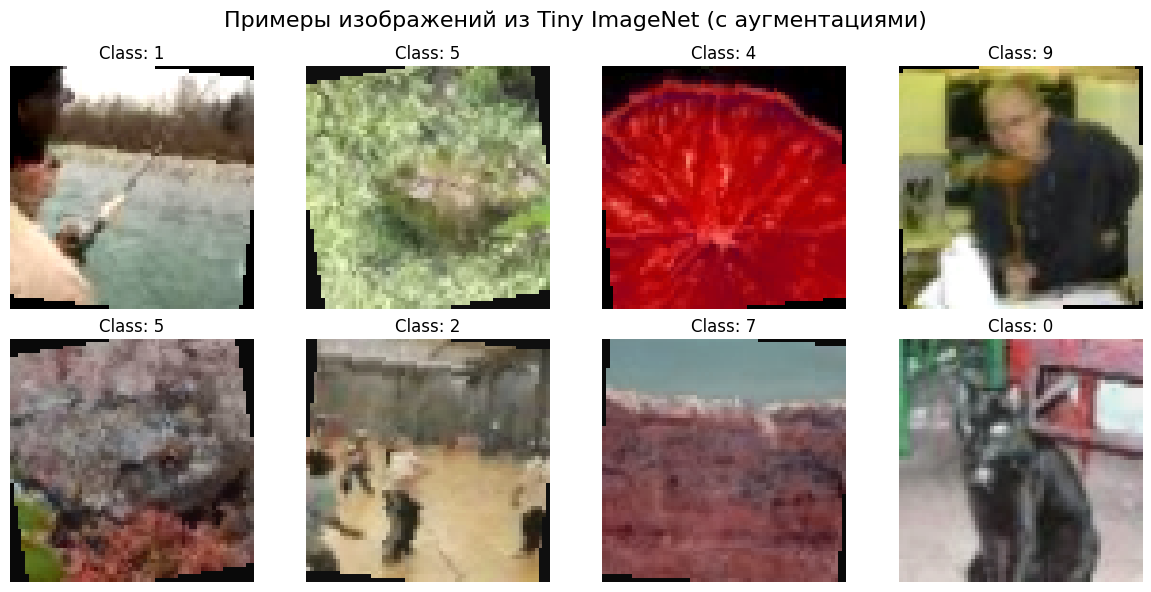

Размер батча: torch.Size([32, 3, 64, 64])
Диапазон значений: [-2.118, 2.640]
Метки классов: [1, 5, 4, 9, 5, 2, 7, 0, 9, 8, 7, 5, 8, 6, 5, 1, 2, 0, 8, 1, 9, 8, 7, 6, 9, 7, 8, 3, 6, 0, 2, 4]
Всего классов в датасете: 200
Примеры названий классов: ['n02124075', 'n04067472', 'n04540053', 'n04099969', 'n07749582']


In [13]:
display_dataset(tiny_train_loader)

In [14]:
# model = CustomSmallResNet18(num_classes=10)
#
# optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
# criterion = nn.CrossEntropyLoss()
# device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
#
# history = train_model(
#     model=model,
#     train_loader=tiny_train_loader,
#     val_loader=tiny_val_loader,
#     optimizer=optimizer,
#     criterion=criterion,
#     device=device,
#     num_epochs=5
# )
#
# plot_training_history(history)


# Модели для экспериментов
## 3.1

In [15]:
class CustomResNetBuilder(nn.Module):
    def __init__(self, custom_block=BasicBlock, layer_shape=[2, 2, 2, 2], activation=nn.ReLU(inplace=True), num_classes=200):
        super().__init__()

        self.custom_block = custom_block
        self.layer_shape = layer_shape
        self.activation = activation
        self.num_classes = num_classes

        # Initial convolution
        self.conv1 = nn.Conv2d(3, 64, kernel_size=7, stride=1, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(64)
        self.maxpool = nn.MaxPool2d(2)

        # Define channel dimensions for each stage
        self.in_channels = 64
        channels = [64, 128, 256, 512]

        # Create layers dynamically
        self.layers = nn.ModuleList()

        # Create each stage
        for i, (num_blocks, out_channels) in enumerate(zip(layer_shape, channels)):
            # First block in the stage might need to handle stride/dimension changes
            stride = 2 if i > 0 else 1  # Downsample in first block of stage 2,3,4

            # Create blocks for this stage
            stage_blocks = []
            for j in range(num_blocks):
                # For the first block in stage (except stage 0), use stride=2
                block_stride = stride if j == 0 else 1

                # Create the block
                block = custom_block(
                    in_channels=self.in_channels,
                    out_channels=out_channels,
                    stride=block_stride,
                    activation=activation
                )
                stage_blocks.append(block)

                # Update in_channels for next block
                self.in_channels = out_channels

            # Add all blocks for this stage
            self.layers.extend(stage_blocks)

        # Adaptive pooling and final layer
        self.adaptive_pooling = nn.AdaptiveAvgPool2d((1, 1))
        self.fc = nn.Linear(channels[len(layer_shape)-1], num_classes)

    def forward(self, x):
        # Initial convolution
        x = self.activation(self.bn1(self.conv1(x)))
        x = self.maxpool(x)

        # Go through all layers
        for layer in self.layers:
            x = layer(x)

        # Final pooling and classification
        x = self.adaptive_pooling(x)
        x = x.view(x.size(0), -1)
        x = self.fc(x)

        return x

    def display(self):
        total_params = sum(p.numel() for p in self.parameters())
        trainable_params = sum(p.numel() for p in self.parameters() if p.requires_grad)
        print(f" Всего параметров: {total_params:,}")
        print(f" Обучаемых параметров: {trainable_params:,}")

    def params(self):
        return sum(p.numel() for p in self.parameters())

In [16]:
# optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
# criterion = nn.CrossEntropyLoss()
# device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
#
# history = train_model(
#     model=model,
#     train_loader=tiny_train_loader,
#     val_loader=tiny_val_loader,
#     optimizer=optimizer,
#     criterion=criterion,
#     device=device,
#     num_epochs=5
# )
#
# plot_training_history(history)

In [ ]:
def RunTrainModels(models, model_names=None, train_loader=tiny_train_loader,
                   val_loader=tiny_val_loader, num_epochs=5, lr=0.001):
    """
    Train multiple models sequentially and plot their training histories.

    Args:
        models: List of model instances
        model_names: List of model names for labeling (optional)
        train_loader: Training data loader
        val_loader: Validation data loader
        num_epochs: Number of epochs to train each model
        lr: Learning rate for optimizer
    """
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    criterion = nn.CrossEntropyLoss()

    all_histories = []

    # If model_names not provided, generate default names
    if model_names is None:
        model_names = [f"Model_{i+1}" for i in range(len(models))]

    for idx, (model, model_name) in enumerate(zip(models, model_names)):
        print(f"\n{'='*60}")
        print(f"Training {model_name} ({idx+1}/{len(models)})")
        print(f"{'='*60}")

        # Move model to device
        model = model.to(device)

        # Count parameters
        total_params = sum(p.numel() for p in model.parameters())
        trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
        print(f"Total parameters: {total_params:,}")
        print(f"Trainable parameters: {trainable_params:,}")

        # Create optimizer
        optimizer = torch.optim.Adam(model.parameters(), lr=lr)

        # Train the model
        history = train_model(
            model=model,
            train_loader=train_loader,
            val_loader=val_loader,
            optimizer=optimizer,
            criterion=criterion,
            device=device,
            num_epochs=num_epochs
        )

        # Store history with model name
        history['model_name'] = model_name
        history['params'] = model.params()

        all_histories.append(history)
        # Plot individual training history
        plot_training_history(history)

        # Free up GPU memory
        del model
        if torch.cuda.is_available():
            torch.cuda.empty_cache()

    # Plot comparison of all models
    plot_comparison(all_histories)

    return all_histories


def plot_comparison(histories):
    """
    Plot comparison of multiple models' training histories.

    Args:
        histories: List of history dictionaries from train_model
    """
    fig, axes = plt.subplots(1, 2, figsize=(15, 5))

    colors = plt.cm.Set3(np.linspace(0, 1, len(histories)))

    # Plot training loss
    ax = axes[0]
    for history, color, model_name in zip(histories, colors, [h['model_name'] for h in histories]):
        ax.plot(history['train_loss'], label=model_name, color=color, linewidth=2)
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Training Loss')
    ax.set_title('Training Loss Comparison')
    ax.legend()
    ax.grid(True, alpha=0.3)

    # Plot validation accuracy
    ax = axes[1]
    for history, color, model_name in zip(histories, colors, [h['model_name'] for h in histories]):
        ax.plot(history['val_acc'], label=model_name, color=color, linewidth=2)
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Validation Accuracy (%)')
    ax.set_title('Validation Accuracy Comparison')
    ax.legend()
    ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

    # Print final metrics comparison
    print("\n" + "="*90)
    print("FINAL METRICS COMPARISON")
    print("="*60)
    print(f"{'Model Name':<20} {'Parameters':<20} {'Train Acc (%):':<15}  {'Val Acc (%):':<15} {'Train Loss:'} {'Val Loss:'}")
    print("-"*60)

    for history in histories:
        model_name = history['model_name']

        parameters = history['params']

        train_acc = history['train_acc'][-1] if history['train_acc'] else 0
        val_acc = history['val_acc'][-1] if history['val_acc'] else 0

        train_loss = history['train_loss'][-1] if history['train_loss'] else 0
        val_loss = history['val_loss'][-1] if history['val_loss'] else 0

        print(f"{model_name:<20} {parameters:<20}  {train_acc:<15.2f}  {val_acc:<15.2f} {train_loss:<.4f} {val_loss:.4f}")


Training 1A: [1,1,1,1] (1/9)
Total parameters: 4,911,818
Trainable parameters: 4,911,818
Обучение на 25 эпох...
 Эпоха 1/25


 Train Loss: 2.0406, Train Acc: 27.22%
 Val Loss: 2.1465, Val Acc: 22.60%
 Сохранена лучшая модель с точностью 22.60%
 Эпоха 2/25


 Train Loss: 1.8290, Train Acc: 35.78%
 Val Loss: 1.8970, Val Acc: 33.20%
 Сохранена лучшая модель с точностью 33.20%
 Эпоха 3/25


 Train Loss: 1.7341, Train Acc: 39.52%
 Val Loss: 1.6608, Val Acc: 41.80%
 Сохранена лучшая модель с точностью 41.80%
 Эпоха 4/25


 Train Loss: 1.6399, Train Acc: 43.42%
 Val Loss: 1.6436, Val Acc: 45.00%
 Сохранена лучшая модель с точностью 45.00%
 Эпоха 5/25


...

 Train Loss: 1.0457, Train Acc: 63.94%
 Val Loss: 1.3287, Val Acc: 53.40%
 Эпоха 22/25


 Train Loss: 1.0254, Train Acc: 64.12%
 Val Loss: 1.3358, Val Acc: 53.60%
 Эпоха 23/25


 Train Loss: 1.0028, Train Acc: 65.18%
 Val Loss: 1.2677, Val Acc: 56.00%
 Сохранена лучшая модель с точностью 56.00%
 Эпоха 24/25


 Train Loss: 0.9984, Train Acc: 66.30%
 Val Loss: 1.2576, Val Acc: 55.80%
 Эпоха 25/25


 Train Loss: 0.9830, Train Acc: 66.28%
 Val Loss: 1.2913, Val Acc: 54.80%


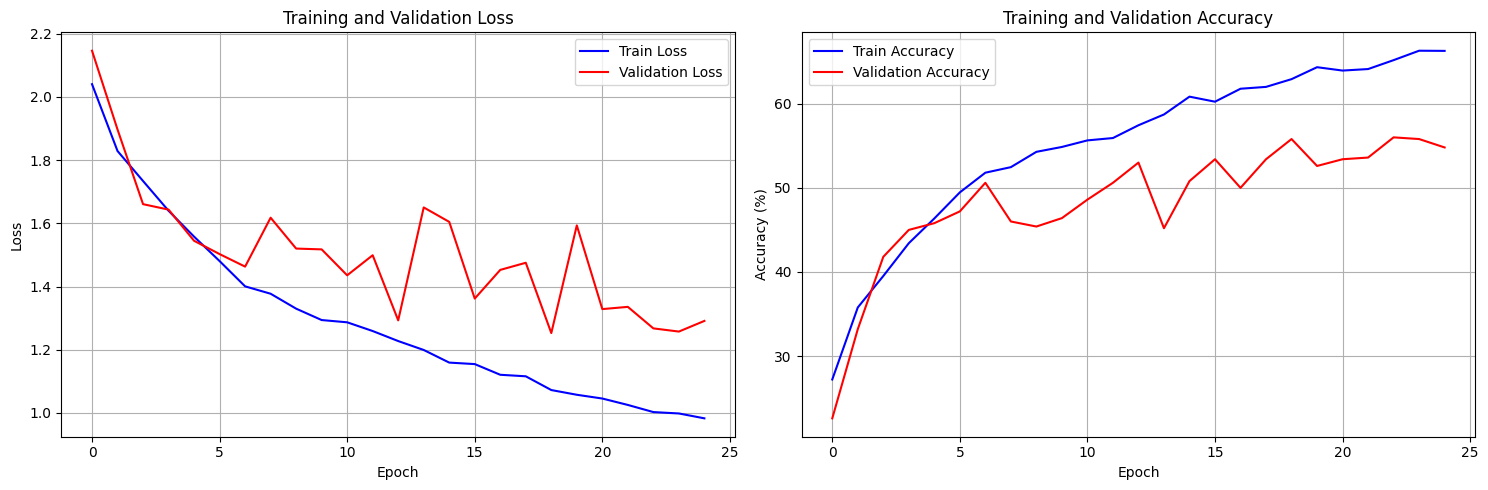


Training 1B: [1,1,1,0] (2/9)
Total parameters: 1,235,658
Trainable parameters: 1,235,658
Обучение на 25 эпох...
 Эпоха 1/25


 Train Loss: 1.9693, Train Acc: 30.58%
 Val Loss: 1.9436, Val Acc: 33.80%
 Сохранена лучшая модель с точностью 33.80%
 Эпоха 2/25


 Train Loss: 1.8109, Train Acc: 36.34%
 Val Loss: 1.7675, Val Acc: 38.00%
 Сохранена лучшая модель с точностью 38.00%
 Эпоха 3/25


 Train Loss: 1.6598, Train Acc: 41.92%
 Val Loss: 1.7619, Val Acc: 40.20%
 Сохранена лучшая модель с точностью 40.20%
 Эпоха 4/25


 Train Loss: 1.5995, Train Acc: 44.98%
 Val Loss: 1.7337, Val Acc: 40.80%
 Сохранена лучшая модель с точностью 40.80%
 Эпоха 5/25


...

 Train Loss: 1.0297, Train Acc: 64.86%
 Val Loss: 1.3693, Val Acc: 55.80%
 Эпоха 22/25


 Train Loss: 1.0421, Train Acc: 65.10%
 Val Loss: 1.5529, Val Acc: 50.20%
 Эпоха 23/25


 Train Loss: 1.0089, Train Acc: 65.62%
 Val Loss: 1.4764, Val Acc: 48.20%
 Эпоха 24/25


 Train Loss: 0.9947, Train Acc: 65.98%
 Val Loss: 1.4274, Val Acc: 54.40%
 Эпоха 25/25


 Train Loss: 0.9791, Train Acc: 66.44%
 Val Loss: 1.3889, Val Acc: 52.80%


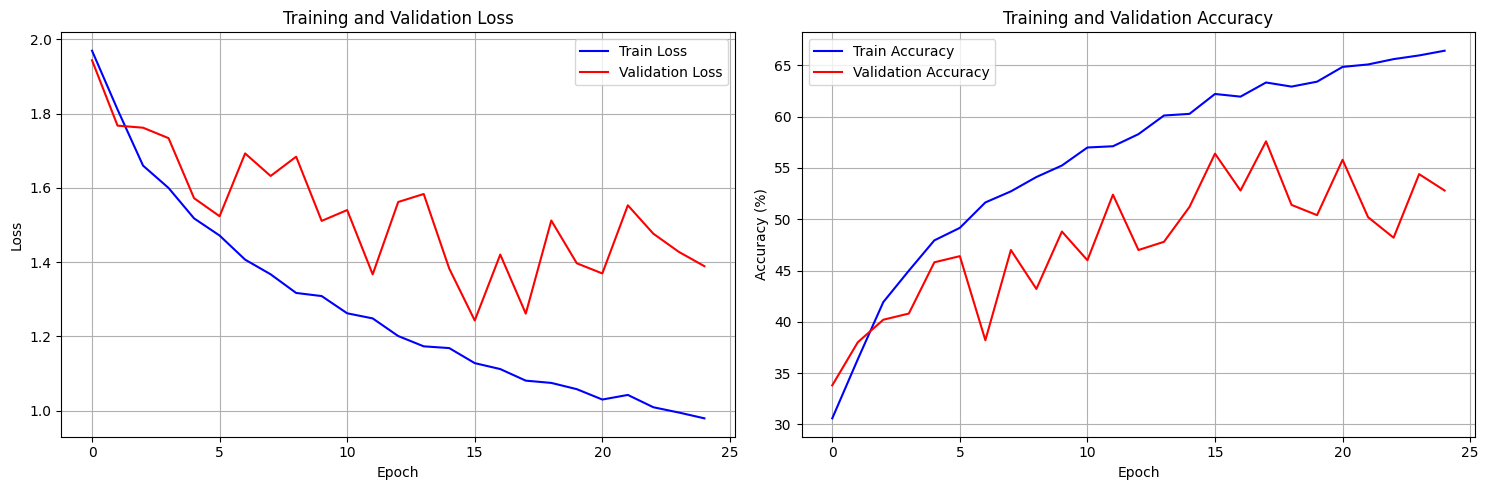


Training 2A: [1,1,1,1] (3/9)
Total parameters: 4,911,818
Trainable parameters: 4,911,818
Обучение на 25 эпох...
 Эпоха 1/25


 Train Loss: 2.0495, Train Acc: 28.06%
 Val Loss: 2.9029, Val Acc: 23.40%
 Сохранена лучшая модель с точностью 23.40%
 Эпоха 2/25


 Train Loss: 1.8254, Train Acc: 35.58%
 Val Loss: 2.0720, Val Acc: 30.00%
 Сохранена лучшая модель с точностью 30.00%
 Эпоха 3/25


 Train Loss: 1.7065, Train Acc: 41.80%
 Val Loss: 1.7410, Val Acc: 39.60%
 Сохранена лучшая модель с точностью 39.60%
 Эпоха 4/25


 Train Loss: 1.6099, Train Acc: 45.06%
 Val Loss: 1.6140, Val Acc: 41.80%
 Сохранена лучшая модель с точностью 41.80%
 Эпоха 5/25


...

 Train Loss: 1.0481, Train Acc: 63.86%
 Val Loss: 1.3524, Val Acc: 52.80%
 Эпоха 22/25


 Train Loss: 1.0023, Train Acc: 65.16%
 Val Loss: 1.4043, Val Acc: 56.60%
 Сохранена лучшая модель с точностью 56.60%
 Эпоха 23/25


 Train Loss: 0.9952, Train Acc: 66.00%
 Val Loss: 1.3067, Val Acc: 57.20%
 Сохранена лучшая модель с точностью 57.20%
 Эпоха 24/25


 Train Loss: 0.9869, Train Acc: 66.38%
 Val Loss: 1.4929, Val Acc: 52.80%
 Эпоха 25/25


 Train Loss: 0.9715, Train Acc: 66.82%
 Val Loss: 1.4466, Val Acc: 55.20%


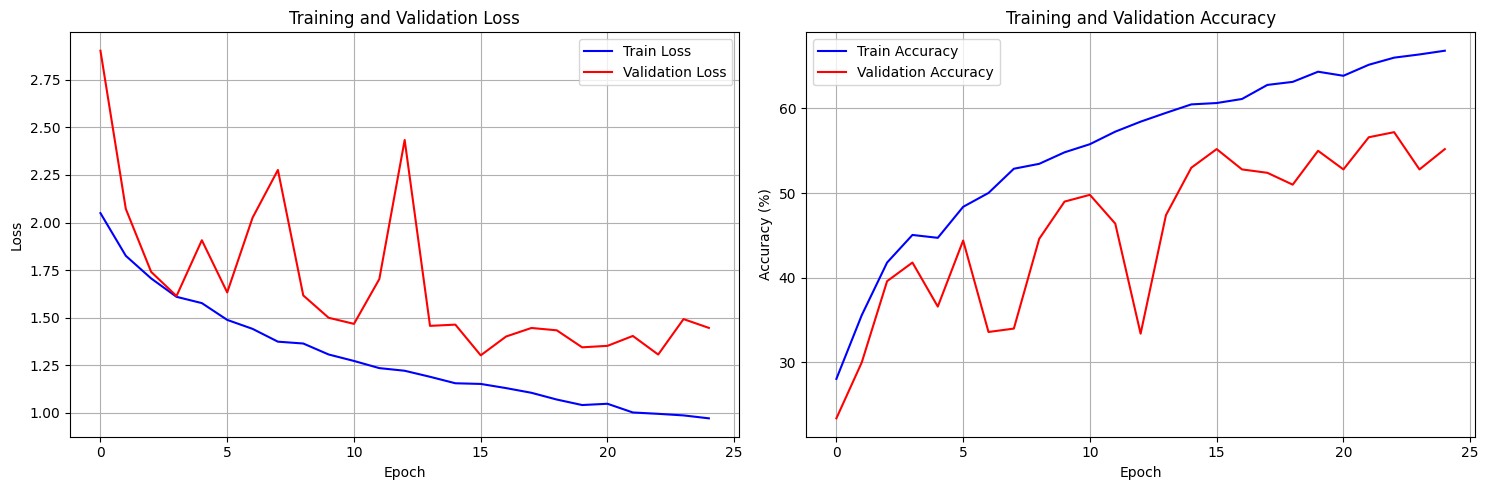


Training 2B: [2,2,2,2] (4/9)
Total parameters: 11,182,538
Trainable parameters: 11,182,538
Обучение на 25 эпох...
 Эпоха 1/25


 Train Loss: 2.1163, Train Acc: 25.16%
 Val Loss: 2.0614, Val Acc: 28.60%
 Сохранена лучшая модель с точностью 28.60%
 Эпоха 2/25


 Train Loss: 1.9178, Train Acc: 33.48%
 Val Loss: 1.8582, Val Acc: 37.80%
 Сохранена лучшая модель с точностью 37.80%
 Эпоха 3/25


 Train Loss: 1.8224, Train Acc: 36.30%
 Val Loss: 1.9350, Val Acc: 36.60%
 Эпоха 4/25


 Train Loss: 1.7395, Train Acc: 39.50%
 Val Loss: 1.9434, Val Acc: 34.40%
 Эпоха 5/25


...

 Train Loss: 1.1126, Train Acc: 61.92%
 Val Loss: 1.3734, Val Acc: 52.40%
 Эпоха 22/25


 Train Loss: 1.0745, Train Acc: 63.16%
 Val Loss: 1.3045, Val Acc: 53.80%
 Сохранена лучшая модель с точностью 53.80%
 Эпоха 23/25


 Train Loss: 1.0752, Train Acc: 63.78%
 Val Loss: 1.2892, Val Acc: 51.40%
 Эпоха 24/25


 Train Loss: 1.0646, Train Acc: 63.48%
 Val Loss: 1.3383, Val Acc: 53.60%
 Эпоха 25/25


 Train Loss: 1.0317, Train Acc: 64.26%
 Val Loss: 1.3875, Val Acc: 49.80%


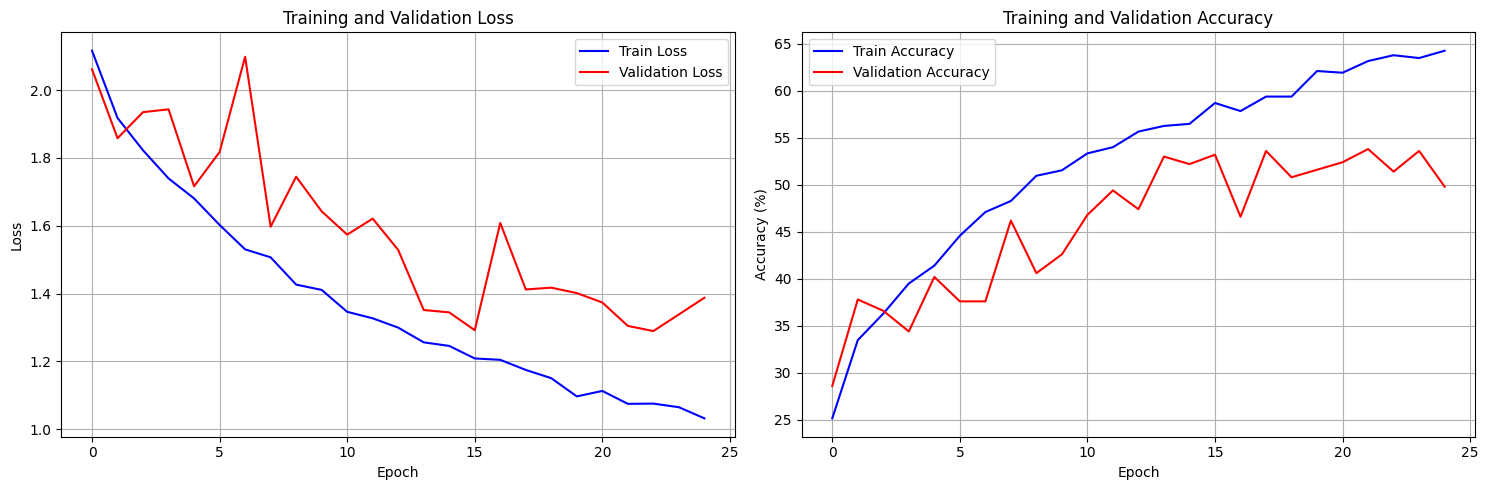


Training 2C: [3,3,3,3] (5/9)
Total parameters: 17,453,258
Trainable parameters: 17,453,258
Обучение на 25 эпох...
 Эпоха 1/25


 Train Loss: 2.1675, Train Acc: 23.34%
 Val Loss: 2.0000, Val Acc: 27.80%
 Сохранена лучшая модель с точностью 27.80%
 Эпоха 2/25


 Train Loss: 1.9552, Train Acc: 29.84%
 Val Loss: 1.9660, Val Acc: 33.60%
 Сохранена лучшая модель с точностью 33.60%
 Эпоха 3/25


 Train Loss: 1.8869, Train Acc: 34.40%
 Val Loss: 2.1789, Val Acc: 33.40%
 Эпоха 4/25


 Train Loss: 1.7979, Train Acc: 37.28%
 Val Loss: 1.8497, Val Acc: 35.60%
 Сохранена лучшая модель с точностью 35.60%
 Эпоха 5/25


...

 Train Loss: 1.1190, Train Acc: 61.44%
 Val Loss: 1.4549, Val Acc: 52.00%
 Сохранена лучшая модель с точностью 52.00%
 Эпоха 22/25


 Train Loss: 1.0980, Train Acc: 62.30%
 Val Loss: 1.4267, Val Acc: 52.40%
 Сохранена лучшая модель с точностью 52.40%
 Эпоха 23/25


 Train Loss: 1.0642, Train Acc: 63.88%
 Val Loss: 1.9336, Val Acc: 48.20%
 Эпоха 24/25


 Train Loss: 1.0947, Train Acc: 62.38%
 Val Loss: 1.7033, Val Acc: 46.20%
 Эпоха 25/25


 Train Loss: 1.0558, Train Acc: 63.08%
 Val Loss: 1.7391, Val Acc: 50.60%


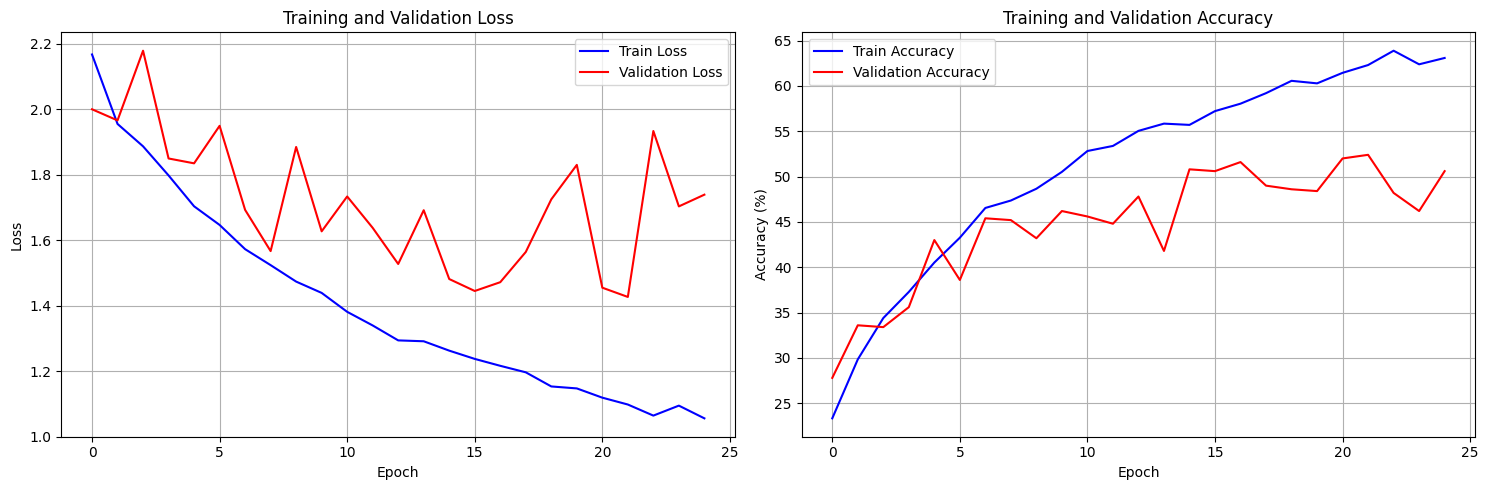


Training 3A: ReLU (6/9)
Total parameters: 11,182,538
Trainable parameters: 11,182,538
Обучение на 25 эпох...
 Эпоха 1/25


 Train Loss: 2.1438, Train Acc: 23.82%
 Val Loss: 2.1426, Val Acc: 25.00%
 Сохранена лучшая модель с точностью 25.00%
 Эпоха 2/25


 Train Loss: 1.9381, Train Acc: 31.60%
 Val Loss: 2.2149, Val Acc: 21.40%
 Эпоха 3/25


 Train Loss: 1.8759, Train Acc: 34.58%
 Val Loss: 1.7713, Val Acc: 40.80%
 Сохранена лучшая модель с точностью 40.80%
 Эпоха 4/25


 Train Loss: 1.7504, Train Acc: 38.62%
 Val Loss: 1.8754, Val Acc: 38.00%
 Эпоха 5/25


...

 Train Loss: 1.0893, Train Acc: 63.12%
 Val Loss: 1.1911, Val Acc: 58.80%
 Сохранена лучшая модель с точностью 58.80%
 Эпоха 22/25


 Train Loss: 1.0703, Train Acc: 63.66%
 Val Loss: 1.2353, Val Acc: 59.60%
 Сохранена лучшая модель с точностью 59.60%
 Эпоха 23/25


 Train Loss: 1.0495, Train Acc: 63.94%
 Val Loss: 1.3376, Val Acc: 56.80%
 Эпоха 24/25


 Train Loss: 1.0317, Train Acc: 65.24%
 Val Loss: 1.4685, Val Acc: 53.20%
 Эпоха 25/25


 Train Loss: 0.9935, Train Acc: 65.88%
 Val Loss: 1.6362, Val Acc: 48.20%


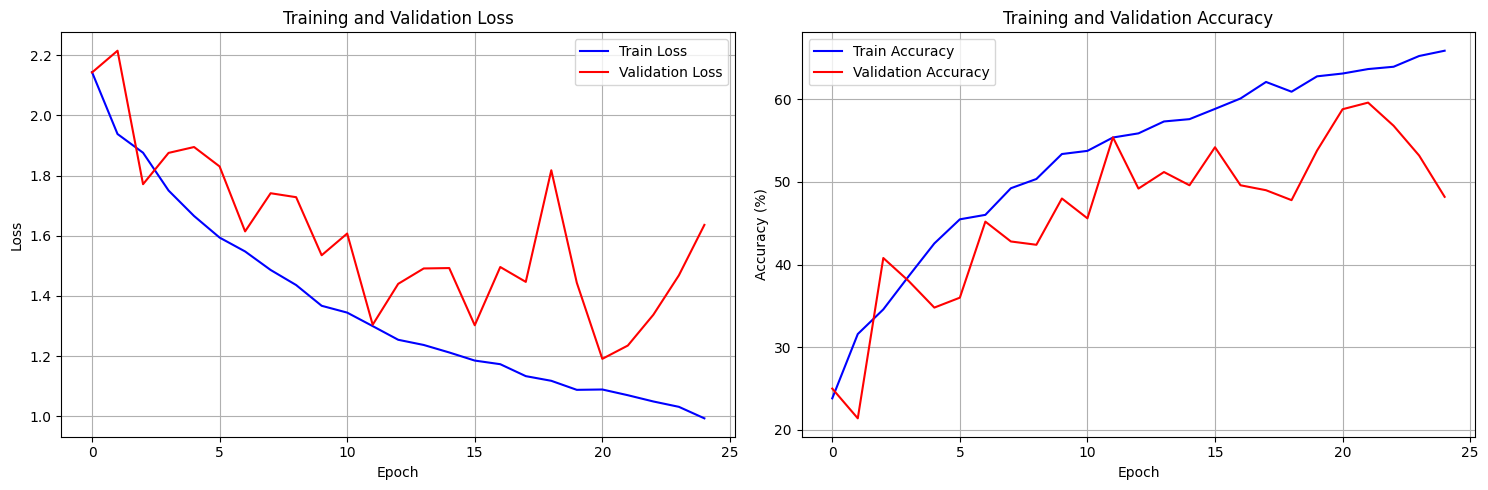


Training 3B: LeakyReLU (7/9)
Total parameters: 11,182,538
Trainable parameters: 11,182,538
Обучение на 25 эпох...
 Эпоха 1/25


 Train Loss: 2.0995, Train Acc: 25.12%
 Val Loss: 2.1303, Val Acc: 24.20%
 Сохранена лучшая модель с точностью 24.20%
 Эпоха 2/25


 Train Loss: 1.9201, Train Acc: 33.54%
 Val Loss: 2.0245, Val Acc: 30.00%
 Сохранена лучшая модель с точностью 30.00%
 Эпоха 3/25


 Train Loss: 1.8091, Train Acc: 37.96%
 Val Loss: 1.7143, Val Acc: 39.40%
 Сохранена лучшая модель с точностью 39.40%
 Эпоха 4/25


 Train Loss: 1.7367, Train Acc: 40.40%
 Val Loss: 1.7872, Val Acc: 40.20%
 Сохранена лучшая модель с точностью 40.20%
 Эпоха 5/25


...

 Train Loss: 1.0896, Train Acc: 62.54%
 Val Loss: 1.6789, Val Acc: 45.80%
 Эпоха 22/25


 Train Loss: 1.0689, Train Acc: 63.88%
 Val Loss: 1.9041, Val Acc: 41.40%
 Эпоха 23/25


 Train Loss: 1.0498, Train Acc: 63.60%
 Val Loss: 1.3624, Val Acc: 53.60%
 Сохранена лучшая модель с точностью 53.60%
 Эпоха 24/25


 Train Loss: 1.0351, Train Acc: 64.64%
 Val Loss: 1.5122, Val Acc: 50.60%
 Эпоха 25/25


 Train Loss: 0.9965, Train Acc: 65.40%
 Val Loss: 1.5329, Val Acc: 50.60%


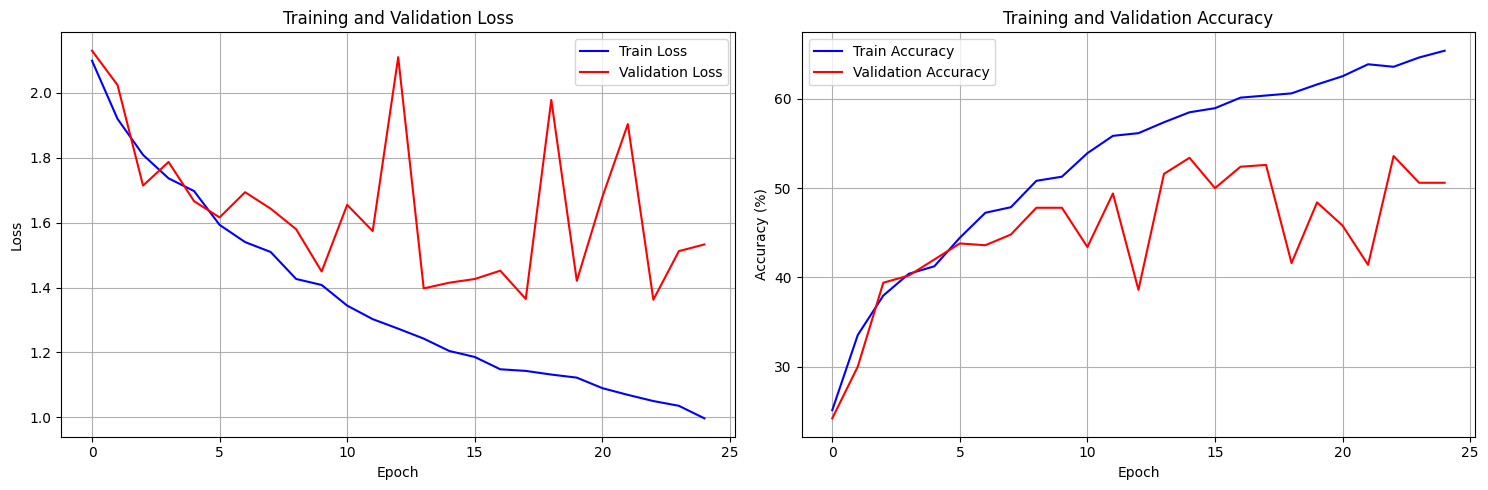


Training 3C: ELU (8/9)
Total parameters: 11,182,538
Trainable parameters: 11,182,538
Обучение на 25 эпох...
 Эпоха 1/25


 Train Loss: 2.1539, Train Acc: 24.04%
 Val Loss: 2.3403, Val Acc: 24.00%
 Сохранена лучшая модель с точностью 24.00%
 Эпоха 2/25


 Train Loss: 1.8960, Train Acc: 34.32%
 Val Loss: 1.9839, Val Acc: 31.40%
 Сохранена лучшая модель с точностью 31.40%
 Эпоха 3/25


 Train Loss: 1.8014, Train Acc: 36.86%
 Val Loss: 1.9293, Val Acc: 33.40%
 Сохранена лучшая модель с точностью 33.40%
 Эпоха 4/25


 Train Loss: 1.7407, Train Acc: 40.10%
 Val Loss: 1.7577, Val Acc: 42.20%
 Сохранена лучшая модель с точностью 42.20%
 Эпоха 5/25


...

 Train Loss: 1.1917, Train Acc: 59.30%
 Val Loss: 1.8270, Val Acc: 41.20%
 Эпоха 22/25


 Train Loss: 1.1701, Train Acc: 59.70%
 Val Loss: 1.3641, Val Acc: 54.40%
 Сохранена лучшая модель с точностью 54.40%
 Эпоха 23/25


 Train Loss: 1.1442, Train Acc: 61.42%
 Val Loss: 1.4274, Val Acc: 51.80%
 Эпоха 24/25


 Train Loss: 1.1479, Train Acc: 60.62%
 Val Loss: 1.5301, Val Acc: 50.60%
 Эпоха 25/25


 Train Loss: 1.1384, Train Acc: 61.70%
 Val Loss: 1.5805, Val Acc: 46.40%


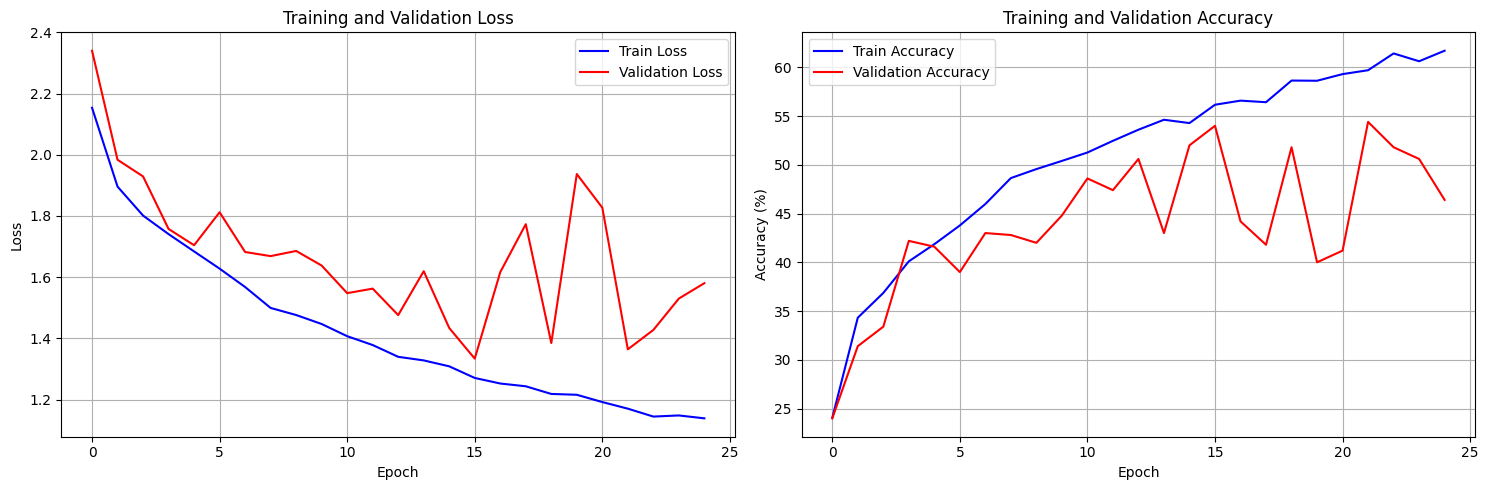


Training 3D: GELU (9/9)
Total parameters: 11,182,538
Trainable parameters: 11,182,538
Обучение на 25 эпох...
 Эпоха 1/25


 Train Loss: 2.0957, Train Acc: 25.82%
 Val Loss: 2.0752, Val Acc: 27.00%
 Сохранена лучшая модель с точностью 27.00%
 Эпоха 2/25


 Train Loss: 1.9223, Train Acc: 32.30%
 Val Loss: 1.9090, Val Acc: 33.60%
 Сохранена лучшая модель с точностью 33.60%
 Эпоха 3/25


 Train Loss: 1.7995, Train Acc: 37.56%
 Val Loss: 1.8781, Val Acc: 34.40%
 Сохранена лучшая модель с точностью 34.40%
 Эпоха 4/25


 Train Loss: 1.7075, Train Acc: 41.62%
 Val Loss: 2.0229, Val Acc: 36.60%
 Сохранена лучшая модель с точностью 36.60%
 Эпоха 5/25


...

 Train Loss: 1.0573, Train Acc: 64.20%
 Val Loss: 1.3196, Val Acc: 55.00%
 Эпоха 22/25


 Train Loss: 1.0344, Train Acc: 63.98%
 Val Loss: 1.3087, Val Acc: 56.80%
 Эпоха 23/25


 Train Loss: 1.0183, Train Acc: 64.50%
 Val Loss: 1.4085, Val Acc: 54.20%
 Эпоха 24/25


 Train Loss: 1.0116, Train Acc: 64.88%
 Val Loss: 1.4625, Val Acc: 54.00%
 Эпоха 25/25


 Train Loss: 0.9910, Train Acc: 65.96%
 Val Loss: 1.2384, Val Acc: 58.40%
 Сохранена лучшая модель с точностью 58.40%


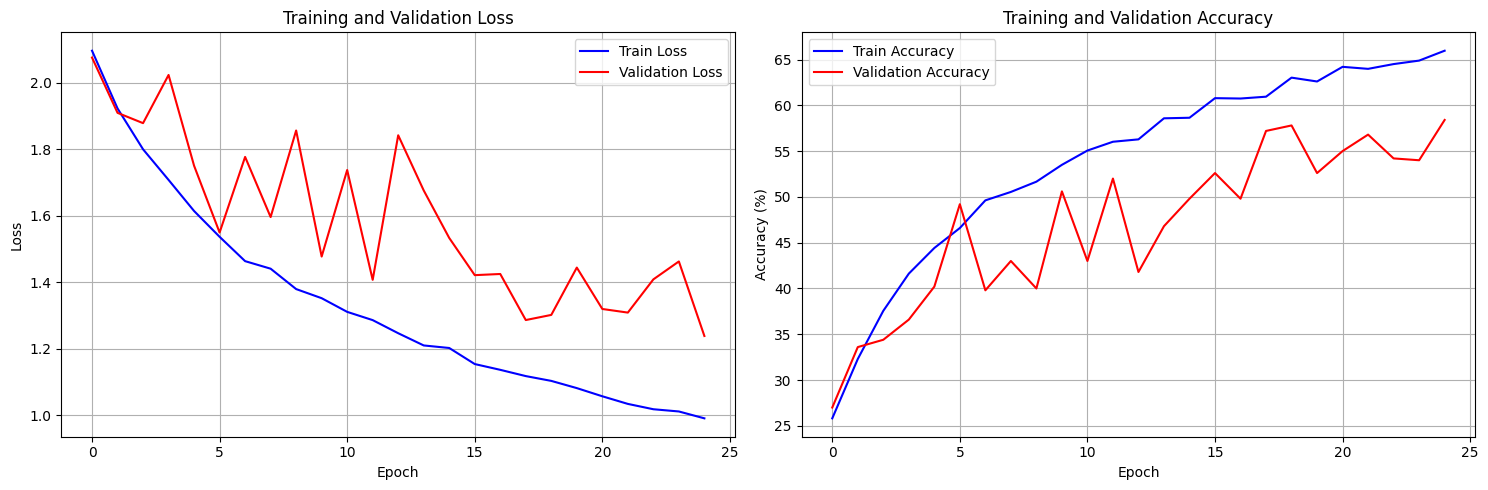

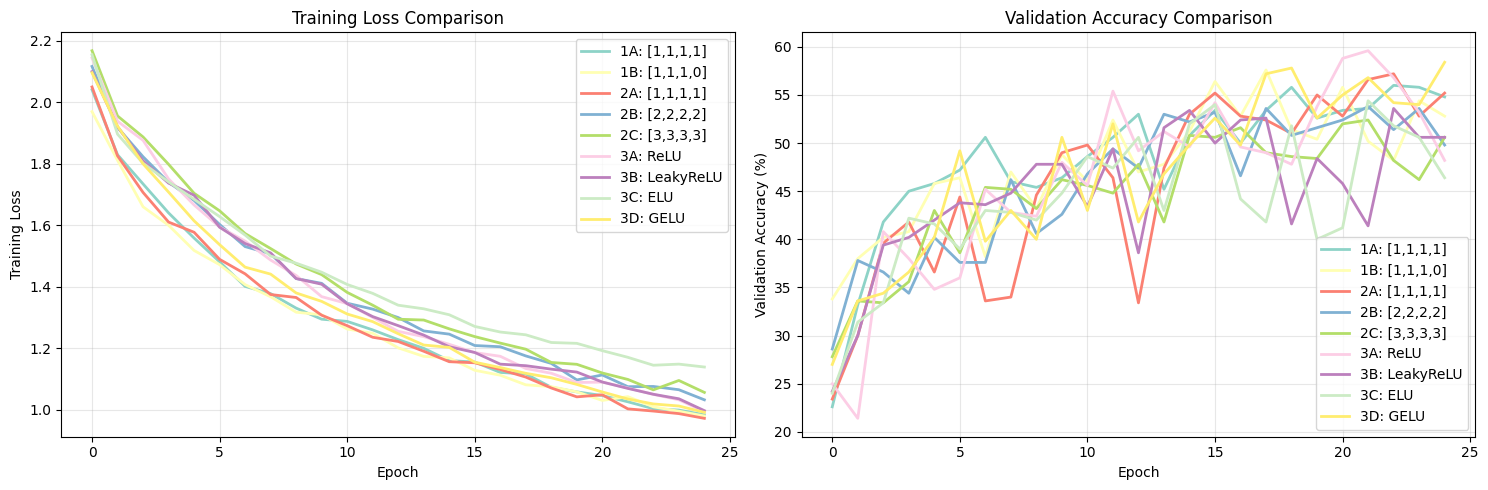


FINAL METRICS COMPARISON
Model Name           Parameters           Train Acc (%):   Val Acc (%):    Train Loss: Val Loss:
------------------------------------------------------------
1A: [1,1,1,1]        4911818               66.28            54.80           0.9830 1.2913
1B: [1,1,1,0]        1235658               66.44            52.80           0.9791 1.3889
2A: [1,1,1,1]        4911818               66.82            55.20           0.9715 1.4466
2B: [2,2,2,2]        11182538              64.26            49.80           1.0317 1.3875
2C: [3,3,3,3]        17453258              63.08            50.60           1.0558 1.7391
3A: ReLU             11182538              65.88            48.20           0.9935 1.6362
3B: LeakyReLU        11182538              65.40            50.60           0.9965 1.5329
3C: ELU              11182538              61.70            46.40           1.1384 1.5805
3D: GELU             11182538              65.96            58.40           0.9910 1.2384


In [18]:
# Create your models
models = [
    #64->128->256->512
    CustomResNetBuilder(layer_shape=[1,1,1,1], num_classes=10),
    #32->128->256
    CustomResNetBuilder(layer_shape=[1,1,1], num_classes=10),

    # 1 layer block
    CustomResNetBuilder(layer_shape=[1, 1, 1, 1], num_classes=10),
    # 2 layer block
    CustomResNetBuilder(layer_shape=[2, 2, 2, 2], num_classes=10),
    # 3 layer block
    CustomResNetBuilder(layer_shape=[3, 3, 3, 3], num_classes=10),

    #activation ReLU
    CustomResNetBuilder(activation=nn.ReLU(inplace=True), layer_shape=[2, 2, 2, 2], num_classes=10),
    #activation LeakyReLU
    CustomResNetBuilder(activation=nn.LeakyReLU(inplace=True), layer_shape=[2, 2, 2, 2], num_classes=10),
    #activation ELU
    CustomResNetBuilder(activation=nn.ELU(inplace=True), layer_shape=[2, 2, 2, 2], num_classes=10),
    #activation GELU
    CustomResNetBuilder(activation=nn.GELU(), layer_shape=[2, 2, 2, 2], num_classes=10)
]

# Optional: Provide descriptive names
model_names = [
    "1A: [1,1,1,1]",
    "1B: [1,1,1,0]",
    "2A: [1,1,1,1]",
    "2B: [2,2,2,2]",
    "2C: [3,3,3,3]",
    "3A: ReLU",
    "3B: LeakyReLU",
    "3C: ELU",
    "3D: GELU"
]

# Train all models
histories = RunTrainModels(
    models=models,
    model_names=model_names,
    train_loader=tiny_train_loader,
    val_loader=tiny_val_loader,
    num_epochs=25,
    lr=0.001
)

### Умная Стратификация

In [79]:
x = []
y = []

val_fraction = round(len(tiny_val_dataset.samples) / (len(tiny_val_dataset.samples) + len(tiny_train_dataset.samples)), 4)
print("valication fraq: ", val_fraction)

joined_samples = tiny_train_dataset.samples + tiny_val_dataset.samples
for i, v in enumerate(joined_samples):
    x.append(v[0])
    y.append(v[1])


skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)


fold_splits = []

for fold, (train_idx, val_idx) in enumerate(skf.split(x, y)):
    train_split = [joined_samples[i] for i in train_idx]
    val_split = [joined_samples[i] for i in val_idx]
    fold_splits.append((train_split, val_split))
    print(f"   Fold {fold}: train={len(train_split)}, val={len(val_split)}")

print(f" Стратифицированное разделение:")
print(f"   Train: {len(train_split)} образцов")
print(f"   Val: {len(val_split)} образцов")


def analyze_class_distribution(samples, name):
    labels = [label for _, label in samples]
    class_counts = Counter(labels)
    print(f" {name} - распределение классов:")
    print(f"   Минимум: {min(class_counts.values())}")
    print(f"   Максимум: {max(class_counts.values())}")
    print(f"   Среднее: {np.mean(list(class_counts.values())):.1f}")
    print(f"   Стандартное отклонение: {np.std(list(class_counts.values())):.1f}")

# Анализируем распределение классов
analyze_class_distribution(train_split, "Стратифицированное train")
analyze_class_distribution(val_split, "Стратифицированное val")

valication fraq:  0.0909
   Fold 0: train=4950, val=550
   Fold 1: train=4950, val=550
   Fold 2: train=4950, val=550
   Fold 3: train=4950, val=550
   Fold 4: train=4950, val=550
   Fold 5: train=4950, val=550
   Fold 6: train=4950, val=550
   Fold 7: train=4950, val=550
   Fold 8: train=4950, val=550
   Fold 9: train=4950, val=550
 Стратифицированное разделение:
   Train: 4950 образцов
   Val: 550 образцов
 Стратифицированное train - распределение классов:
   Минимум: 495
   Максимум: 495
   Среднее: 495.0
   Стандартное отклонение: 0.0
 Стратифицированное val - распределение классов:
   Минимум: 55
   Максимум: 55
   Среднее: 55.0
   Стандартное отклонение: 0.0



Training GELU [1,1,1,1] (1/1)
Total parameters: 4,911,818
Trainable parameters: 4,911,818
Обучение на 30 эпох...
 Эпоха 1/30


 Train Loss: 2.4660, Train Acc: 18.36%
 Val Loss: 2.2902, Val Acc: 15.27%
 Сохранена лучшая модель с точностью 15.27%
 Эпоха 2/30


 Train Loss: 2.1327, Train Acc: 24.73%
 Val Loss: 2.4209, Val Acc: 24.00%
 Сохранена лучшая модель с точностью 24.00%
 Эпоха 3/30


 Train Loss: 2.0378, Train Acc: 29.27%
 Val Loss: 2.3974, Val Acc: 25.64%
 Сохранена лучшая модель с точностью 25.64%
 Эпоха 4/30


 Train Loss: 1.9460, Train Acc: 30.73%
 Val Loss: 2.1408, Val Acc: 29.09%
 Сохранена лучшая модель с точностью 29.09%
 Эпоха 5/30


...

 Train Loss: 1.3476, Train Acc: 54.73%
 Val Loss: 1.6317, Val Acc: 46.91%
 Эпоха 27/30


 Train Loss: 1.3611, Train Acc: 52.00%
 Val Loss: 1.4016, Val Acc: 50.00%
 Эпоха 28/30


 Train Loss: 1.3599, Train Acc: 53.09%
 Val Loss: 1.4266, Val Acc: 53.64%
 Сохранена лучшая модель с точностью 53.64%
 Эпоха 29/30


 Train Loss: 1.3445, Train Acc: 55.64%
 Val Loss: 1.3718, Val Acc: 52.91%
 Эпоха 30/30


 Train Loss: 1.2812, Train Acc: 55.45%
 Val Loss: 1.3247, Val Acc: 53.27%


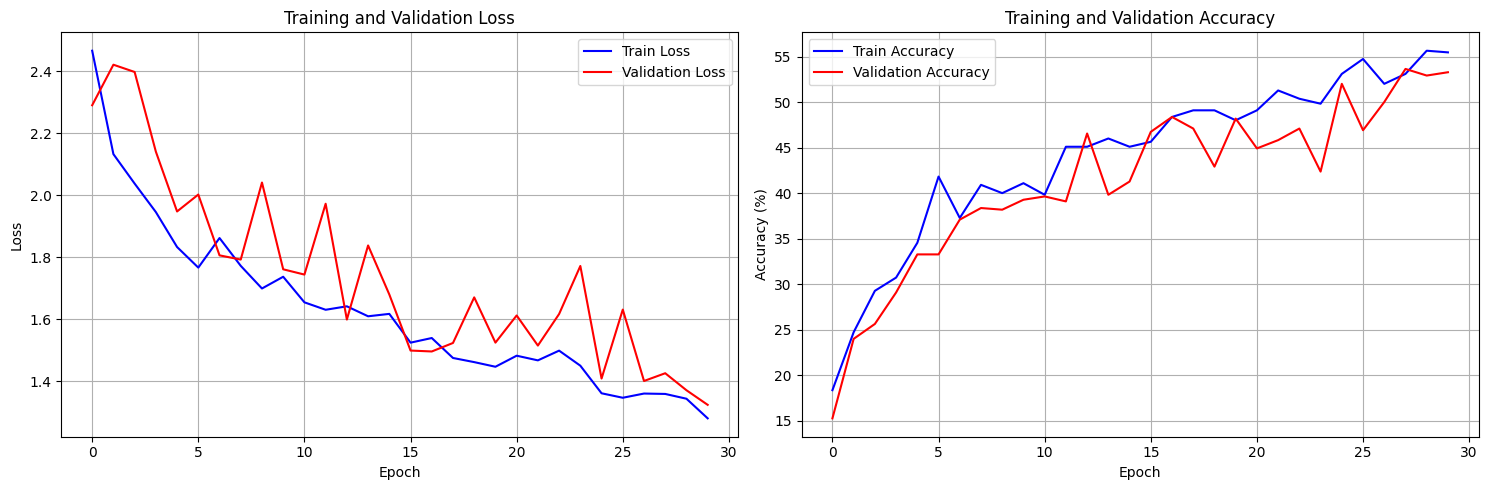

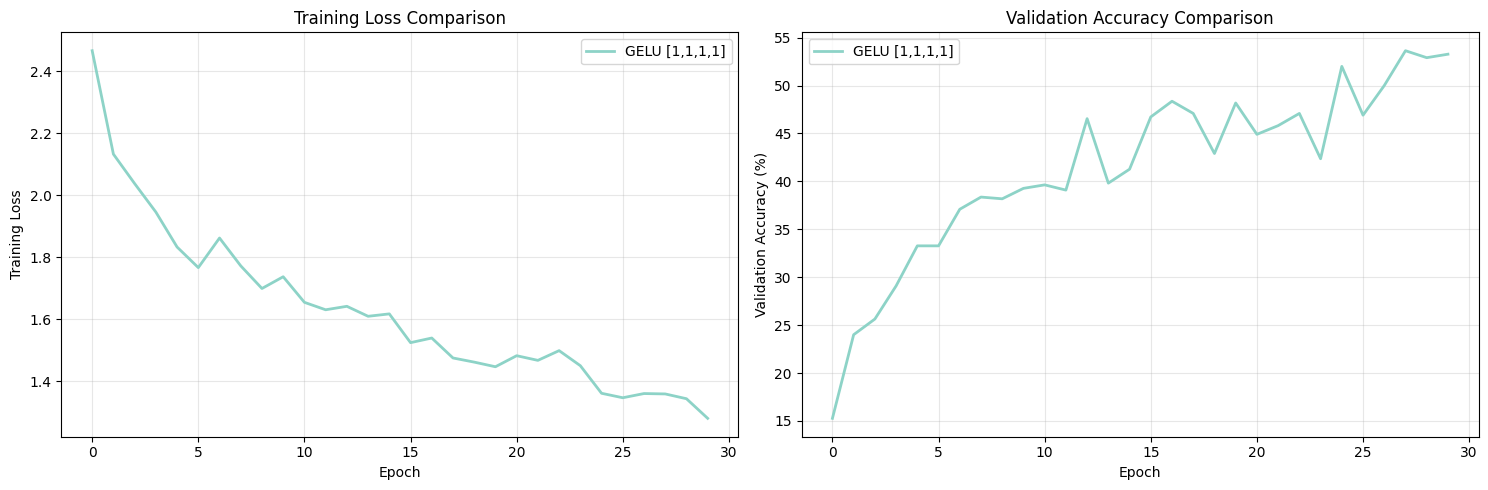


FINAL METRICS COMPARISON
Model Name           Parameters           Train Acc (%):   Val Acc (%):    Train Loss: Val Loss:
------------------------------------------------------------
GELU [1,1,1,1]       4911818               55.45            53.27           1.2812 1.3247


In [91]:
stratisfied_train_dataset = tiny_train_dataset
stratisfied_val_dataset = tiny_train_dataset

stratisfied_train_dataset.samples = train_split
stratisfied_val_dataset.samples = val_split

stratisfied_train_loader = DataLoader(stratisfied_train_dataset, batch_size=128, shuffle=True, num_workers=8)
stratisfied_val_loader = DataLoader(stratisfied_val_dataset, batch_size=128, shuffle=False, num_workers=8)   

# Create your models
models = [
    CustomResNetBuilder(activation=nn.GELU(), layer_shape=[1, 1, 1, 1], num_classes=10),
]

# Optional: Provide descriptive names
model_names = [
    "GELU [1,1,1,1]"
]

# Train all models
histories = RunTrainModels(
    models=models,
    model_names=model_names,
    train_loader=stratisfied_train_loader,
    val_loader=stratisfied_val_loader,
    num_epochs=30,
    lr=0.001
)